<a href="https://colab.research.google.com/github/claudia-miranda/pokemon-ecology/blob/main/Pokemon_Ecology_teacher_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ==============================================================================
# ⚡ POKÉMON SAFARI ZONE SPATIAL MODEL (TEACHER SOLUTION - FAST ANIMATION)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

np.random.seed(42)

# --- GLOBAL SIMULATION PARAMETERS ---
L = 50.0          # Size of grid (50x50 meters)
dt = 0.1          # Time step in minutes (0.1 min = 6 seconds)
Tfinal = 60.0     # Total simulation time in minutes
steps = int(Tfinal / dt)
D = 1.0           # Diffusion speed (m^2 / min)

def update_positions(pos, D, dt, L):
    """Moves Pokémon using 2D Brownian Motion."""
    num_pkm = len(pos)
    if num_pkm == 0:
        return pos

    step_scale = np.sqrt(2 * D * dt)
    pos[:, 0] += step_scale * np.random.normal(size=num_pkm)
    pos[:, 1] += step_scale * np.random.normal(size=num_pkm)  # SOLUTION 1

    return pos % L

def evolve_population(pos, b, d_vector, dt, L, split_dist=0.2):
    """Evaluates birth and death events for individuals."""
    num_pkm = len(pos)
    if num_pkm == 0:
        return pos

    surviving_indices = []
    new_borns = []

    for i in range(num_pkm):
        r_birth = np.random.rand()
        r_death = np.random.rand()

        if r_death < (d_vector[i] * dt):
            continue

        surviving_indices.append(i)

        # SOLUTION 2
        if r_birth < (b * dt):
            theta = np.random.rand() * 2 * np.pi
            child_x = pos[i, 0] + split_dist * np.cos(theta)
            child_y = pos[i, 1] + split_dist * np.sin(theta)
            new_borns.append([child_x, child_y])

    surviving_pos = pos[surviving_indices] if len(surviving_indices) > 0 else np.empty((0, 2))

    if len(new_borns) > 0:
        all_pos = np.vstack([surviving_pos, np.array(new_borns)])
    else:
        all_pos = surviving_pos

    return all_pos % L

def get_local_densities(pos1, pos2, l_radius, L):
    """Fast vectorized density calculation accounting for periodic boundaries."""
    n1, n2 = len(pos1), len(pos2)
    if n1 == 0 or n2 == 0:
        return np.zeros(n1)

    dx = np.abs(pos1[:, 0, None] - pos2[:, 0])
    dy = np.abs(pos1[:, 1, None] - pos2[:, 1])

    dx = np.minimum(dx, L - dx)
    dy = np.minimum(dy, L - dy)

    dist_matrix = np.sqrt(dx**2 + dy**2)
    counts = np.sum(dist_matrix < l_radius, axis=1)

    if np.array_equal(pos1, pos2):
        counts = np.maximum(0, counts - 1)

    return counts / (np.pi * l_radius**2)


# --- PART 1 ---
# Pikachu Single-Species Parameters
N0 = 10
b_N = 0.08      # Birth rate (per min)
d_0 = 0.01      # Baseline death rate (per min)
d_1 = 0.00005   # Intra-species crowding factor
l_N = 3.0       # Sensing radius (meters)

pikachu_pos = np.random.rand(N0, 2) * L

pika_history_pos = []
pika_history_counts = []

for step in range(steps):
    n_pika = len(pikachu_pos)
    rho_NN = get_local_densities(pikachu_pos, pikachu_pos, l_N, L) if n_pika > 0 else np.zeros(0)
    d_pikachu = d_0 + d_1 * (rho_NN * L**2)

    pikachu_pos = update_positions(pikachu_pos, D, dt, L)
    pikachu_pos = evolve_population(pikachu_pos, b_N, d_pikachu, dt, L)

    pika_history_pos.append(pikachu_pos.copy())
    pika_history_counts.append(len(pikachu_pos))

sample_stride = 5
sampled_frames = range(0, steps, sample_stride)

fig1, (ax1_map, ax1_graph) = plt.subplots(1, 2, figsize=(12, 5))

def animate_part1(frame_idx):
    ax1_map.clear()
    ax1_graph.clear()

    pos = pika_history_pos[frame_idx]
    if len(pos) > 0:
        ax1_map.scatter(pos[:, 0], pos[:, 1], color='gold', edgecolor='black', s=50)
    ax1_map.set_xlim(0, L); ax1_map.set_ylim(0, L)
    ax1_map.set_title(f"Part 1: Pikachu Only (t = {frame_idx * dt:.1f} mins)")

    time_axis = np.arange(frame_idx + 1) * dt
    ax1_graph.plot(time_axis, pika_history_counts[:frame_idx + 1], color='gold', lw=2, label='Pikachu')
    ax1_graph.set_xlim(0, Tfinal); ax1_graph.set_xlabel("Time (mins)"); ax1_graph.set_ylabel("Count")
    ax1_graph.set_title("Single Species Logistic Growth")
    ax1_graph.grid(True, alpha=0.3)

anim1 = FuncAnimation(fig1, animate_part1, frames=sampled_frames, interval=50, repeat=False)
plt.close(fig1)
HTML(anim1.to_html5_video())




In [8]:
# --- PART 2 ---
# Two-Species Parameters
P0 = 10
b_P = 0.08
d_P = 0.01
l_P = 3.0

a_N, a_P = 0.0005, 0.0005  # Self-competition
c_N = 0.0030               # Penalty on Pikachu from Charmander
c_P = 0.0010               # Penalty on Charmander from Pikachu

pikachu_pos = np.random.rand(N0, 2) * L
charmander_pos = np.random.rand(P0, 2) * L

pika_history_pos2 = []
charm_history_pos2 = []
pika_counts2 = []
charm_counts2 = []

for step in range(steps):
    n_pika = len(pikachu_pos)
    n_char = len(charmander_pos)

    # SOLUTION 3
    rho_NN = get_local_densities(pikachu_pos, pikachu_pos, l_N, L) if n_pika > 0 else np.zeros(0)
    rho_PP = get_local_densities(charmander_pos, charmander_pos, l_P, L) if n_char > 0 else np.zeros(0)

    rho_NP = get_local_densities(pikachu_pos, charmander_pos, l_N, L) if n_pika > 0 else np.zeros(0)  # SOLUTION
    rho_PN = get_local_densities(charmander_pos, pikachu_pos, l_P, L) if n_char > 0 else np.zeros(0)  # SOLUTION

    d_pikachu = d_0 + (a_N * rho_NN + c_N * rho_NP) * (L**2)
    d_charmander = d_P + (a_P * rho_PP + c_P * rho_PN) * (L**2)

    pikachu_pos = update_positions(pikachu_pos, D, dt, L)
    charmander_pos = update_positions(charmander_pos, D, dt, L)

    pikachu_pos = evolve_population(pikachu_pos, b_N, d_pikachu, dt, L)
    charmander_pos = evolve_population(charmander_pos, b_P, d_charmander, dt, L)

    pika_history_pos2.append(pikachu_pos.copy())
    charm_history_pos2.append(charmander_pos.copy())
    pika_counts2.append(len(pikachu_pos))
    charm_counts2.append(len(charmander_pos))

fig2, (ax2_map, ax2_graph) = plt.subplots(1, 2, figsize=(12, 5))

def animate_part2(frame_idx):
    ax2_map.clear()
    ax2_graph.clear()

    pos_pika = pika_history_pos2[frame_idx]
    pos_charm = charm_history_pos2[frame_idx]

    if len(pos_pika) > 0:
        ax2_map.scatter(pos_pika[:, 0], pos_pika[:, 1], color='gold', edgecolor='black', s=50, label='Pikachu')
    if len(pos_charm) > 0:
        ax2_map.scatter(pos_charm[:, 0], pos_charm[:, 1], color='orangered', edgecolor='black', s=50, label='Charmander')

    ax2_map.set_xlim(0, L); ax2_map.set_ylim(0, L)
    ax2_map.set_title(f"Part 2: Co-Culture Competition (t = {frame_idx * dt:.1f} mins)")
    ax2_map.legend(loc="upper right")

    time_axis = np.arange(frame_idx + 1) * dt
    ax2_graph.plot(time_axis, pika_counts2[:frame_idx + 1], color='gold', lw=2, label='Pikachu')
    ax2_graph.plot(time_axis, charm_counts2[:frame_idx + 1], color='orangered', lw=2, label='Charmander')
    ax2_graph.set_xlim(0, Tfinal); ax2_graph.set_xlabel("Time (mins)"); ax2_graph.set_ylabel("Count")
    ax2_graph.set_title("Two-Species Competitive Exclusion")
    ax2_graph.legend(loc="upper left")
    ax2_graph.grid(True, alpha=0.3)

anim2 = FuncAnimation(fig2, animate_part2, frames=sampled_frames, interval=50, repeat=False)
plt.close(fig2)
HTML(anim2.to_html5_video())

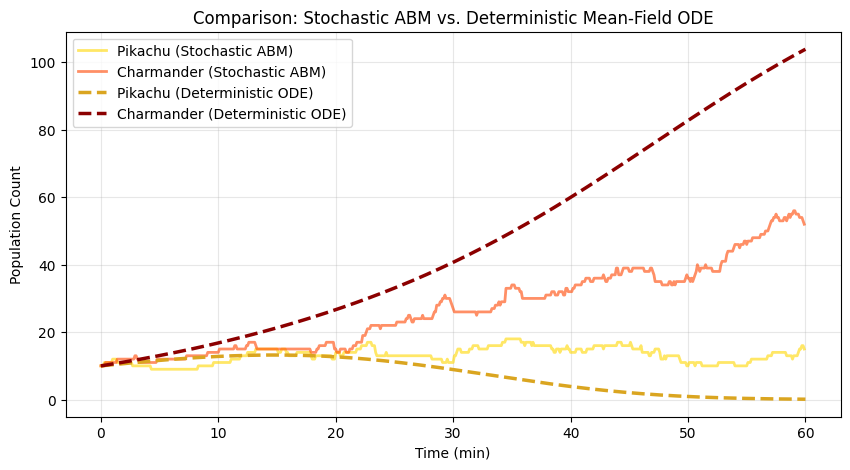

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define ODE derivative function
def competition_ode(t, y, b_N, b_P, d_N, d_P, a_N, a_P, c_N, c_P):
    N, P = y
    dN_dt = b_N * N - (d_N + a_N * N + c_N * P) * N
    dP_dt = b_P * P - (d_P + a_P * P + c_P * N) * P
    return [dN_dt, dP_dt]

# Solve ODE numerically
t_span = (0, Tfinal)
t_eval = np.linspace(0, Tfinal, 200)
y0 = [N0, P0]

sol = solve_ivp(
    competition_ode, t_span, y0, t_eval=t_eval,
    args=(b_N, b_P, d_0, d_P, a_N, a_P, c_N, c_P)
)

# Plot Comparison
plt.figure(figsize=(10, 5))
time_axis = np.arange(steps) * dt

# ABM Stochastic Results
plt.plot(time_axis, pika_counts2, color='gold', alpha=0.6, lw=2, label='Pikachu (Stochastic ABM)')
plt.plot(time_axis, charm_counts2, color='orangered', alpha=0.6, lw=2, label='Charmander (Stochastic ABM)')

# Deterministic ODE Results
plt.plot(sol.t, sol.y[0], color='goldenrod', linestyle='--', lw=2.5, label='Pikachu (Deterministic ODE)')
plt.plot(sol.t, sol.y[1], color='darkred', linestyle='--', lw=2.5, label='Charmander (Deterministic ODE)')

plt.xlabel("Time (min)")
plt.ylabel("Population Count")
plt.title("Comparison: Stochastic ABM vs. Deterministic Mean-Field ODE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🔄 Running 50 stochastic ABM simulations... Please wait a moment.
✅ 50 ABM Simulations Complete!


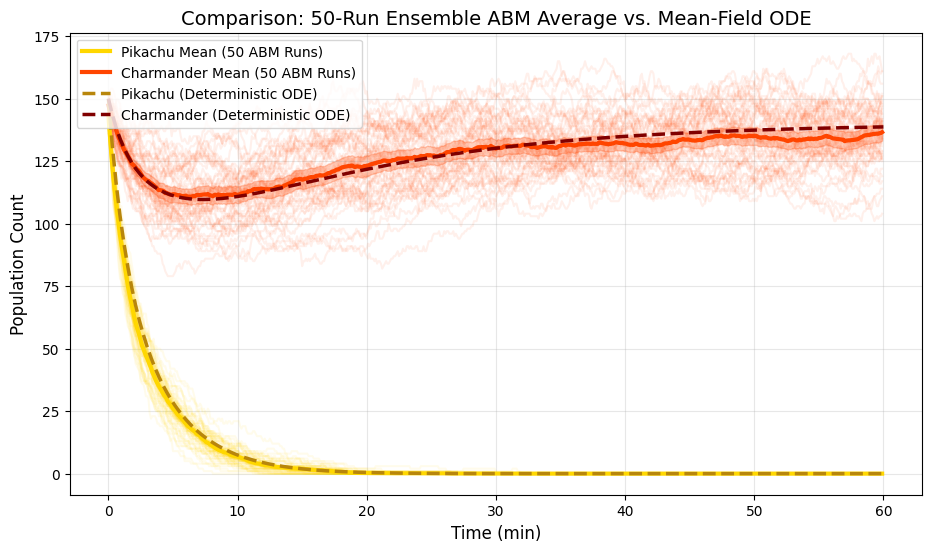

In [15]:
# ==============================================================================
# 50-RUN ENSEMBLE ABM vs. MEAN-FIELD ODE COMPARISON
# ==============================================================================

num_runs = 50

# --- GLOBAL SIMULATION PARAMETERS ---
L = 50.0          # Size of grid (50x50 meters)
dt = 0.1          # Time step in minutes (0.1 min = 6 seconds)
Tfinal = 60.0     # Total simulation time in minutes
steps = int(Tfinal / dt)
D = 1.0         # Diffusion speed (m^2 / min)

# Pikachu Parameters
N0 = 150
b_N = 0.08      # Birth rate (per min)
d_0 = 0.01      # Baseline death rate (per min)
d_1 = 0.00005   # Intra-species crowding factor
l_N = 20       # Sensing radius (meters)

# Charmander Parameters
P0 = 150
b_P = 0.08
d_P = 0.01
l_P = 20

# Interaction Parameters
a_N, a_P = 0.0005, 0.0005  # Self-competition
c_N = 0.0030               # Penalty on Pikachu from Charmander
c_P = 0.0010               # Penalty on Charmander from Pikachu

print(f"🔄 Running {num_runs} stochastic ABM simulations... Please wait a moment.")

# Arrays to store trajectory counts for all 50 runs
# Shape: (num_runs, steps)
all_pika_counts = np.zeros((num_runs, steps))
all_charm_counts = np.zeros((num_runs, steps))

# --- 1. RUN STOCHASTIC ENSEMBLE ---
for run in range(num_runs):
    # Re-initialize random positions for each simulation run
    pikachu_pos = np.random.rand(N0, 2) * L
    charmander_pos = np.random.rand(P0, 2) * L

    for step in range(steps):
        n_pika = len(pikachu_pos)
        n_char = len(charmander_pos)

        # Calculate local densities
        rho_NN = get_local_densities(pikachu_pos, pikachu_pos, l_N, L) if n_pika > 0 else np.zeros(0)
        rho_PP = get_local_densities(charmander_pos, charmander_pos, l_P, L) if n_char > 0 else np.zeros(0)
        rho_NP = get_local_densities(pikachu_pos, charmander_pos, l_N, L) if n_pika > 0 else np.zeros(0)
        rho_PN = get_local_densities(charmander_pos, pikachu_pos, l_P, L) if n_char > 0 else np.zeros(0)

        # Death rates
        d_pikachu = d_0 + (a_N * rho_NN + c_N * rho_NP) * (L**2)
        d_charmander = d_P + (a_P * rho_PP + c_P * rho_PN) * (L**2)

        # Move and evolve
        pikachu_pos = update_positions(pikachu_pos, D, dt, L)
        charmander_pos = update_positions(charmander_pos, D, dt, L)

        pikachu_pos = evolve_population(pikachu_pos, b_N, d_pikachu, dt, L)
        charmander_pos = evolve_population(charmander_pos, b_P, d_charmander, dt, L)

        # Save counts
        all_pika_counts[run, step] = len(pikachu_pos)
        all_charm_counts[run, step] = len(charmander_pos)

print("✅ 50 ABM Simulations Complete!")

# --- 2. CALCULATE MEAN AND STANDARD ERROR ---
mean_pika = np.mean(all_pika_counts, axis=0)
mean_charm = np.mean(all_charm_counts, axis=0)

sem_pika = np.std(all_pika_counts, axis=0) / np.sqrt(num_runs)
sem_charm = np.std(all_charm_counts, axis=0) / np.sqrt(num_runs)

# --- 3. SOLVE CONTINUOUS ODE MODEL ---
def competition_ode(t, y, b_N, b_P, d_N, d_P, a_N, a_P, c_N, c_P):
    N, P = y
    dN_dt = b_N * N - (d_N + a_N * N + c_N * P) * N
    dP_dt = b_P * P - (d_P + a_P * P + c_P * N) * P
    return [dN_dt, dP_dt]

t_span = (0, Tfinal)
t_eval = np.linspace(0, Tfinal, 200)
y0 = [N0, P0]

sol = solve_ivp(
    competition_ode, t_span, y0, t_eval=t_eval,
    args=(b_N, b_P, d_0, d_P, a_N, a_P, c_N, c_P)
)

# --- 4. PLOT COMPARISON ---
plt.figure(figsize=(11, 6))
time_axis = np.arange(steps) * dt

# Individual ABM Runs (Faint background lines)
for run in range(num_runs):
    plt.plot(time_axis, all_pika_counts[run], color='gold', alpha=0.08)
    plt.plot(time_axis, all_charm_counts[run], color='orangered', alpha=0.08)

# Ensemble Average Lines
plt.plot(time_axis, mean_pika, color='gold', lw=3, label=f'Pikachu Mean ({num_runs} ABM Runs)')
plt.fill_between(time_axis, mean_pika - 1.96 * sem_pika, mean_pika + 1.96 * sem_pika, color='gold', alpha=0.25)

plt.plot(time_axis, mean_charm, color='orangered', lw=3, label=f'Charmander Mean ({num_runs} ABM Runs)')
plt.fill_between(time_axis, mean_charm - 1.96 * sem_charm, mean_charm + 1.96 * sem_charm, color='orangered', alpha=0.25)

# Deterministic ODE Curves
plt.plot(sol.t, sol.y[0], color='darkgoldenrod', linestyle='--', lw=2.5, label='Pikachu (Deterministic ODE)')
plt.plot(sol.t, sol.y[1], color='maroon', linestyle='--', lw=2.5, label='Charmander (Deterministic ODE)')

plt.xlabel("Time (min)", fontsize=12)
plt.ylabel("Population Count", fontsize=12)
plt.title("Comparison: 50-Run Ensemble ABM Average vs. Mean-Field ODE", fontsize=14)
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()